In [1]:
import os
import glob
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

In [2]:
def file_to_vector_array(file_path, n_mels=128, frames=5, n_fft=1024, hop_length=512, power=2.0):
    dims = n_mels * frames

    y, sr = librosa.load(file_path, sr=None, mono=True)
    mel_spectrogram = librosa.feature.melspectrogram(y=y,
                                                     sr=sr,
                                                     n_fft=n_fft,
                                                     hop_length=hop_length,
                                                     n_mels=n_mels,
                                                     power=power)

    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max).astype(np.float32)

    vector_array_size = len(log_mel_spectrogram[0, :]) - frames + 1

    if vector_array_size < 1:
        return np.empty((0, dims))

    vector_array = np.zeros((vector_array_size, dims))
    for t in range(frames):
        vector_array[:, n_mels * t: n_mels * (t + 1)] = log_mel_spectrogram[:, t: t + vector_array_size].T

    return vector_array

def list_to_vector_array(file_list, n_mels=128, frames=5, n_fft=1024, hop_length=512, power=2.0):
    all_vectors = []
    for file in file_list:
        vectors = file_to_vector_array(file, n_mels=n_mels, frames=frames, n_fft=n_fft, hop_length=hop_length, power=power)
        all_vectors.append(vectors)

    return np.vstack(all_vectors)

def list_wavs_by_machine_id(train_dir, machine_id):
    training_list_path = os.path.relpath("../dataset/{dir}/*_id_{id}_*.wav".format(dir=train_dir, id=machine_id))
    files = sorted(glob.glob(training_list_path))
    return files

def visualize_baseline_error_map(file_path, model, scaler, n_mels=128, frames=5):
    vectors = file_to_vector_array(file_path, n_mels=n_mels, frames=frames)
    vectors_scaled = scaler.transform(vectors)
    
    reconstructed_scaled = model.predict(vectors_scaled, verbose=0)
    
    error = np.square(vectors_scaled - reconstructed_scaled)
    
    # Promediamos el error de los 'frames' solapados para obtener un mapa 2D (Tiempo x Frecuencia)
    # Una forma simple es tomar el error correspondiente al frame central de cada vector
    error_map = error[:, :n_mels].T # Tomamos el primer frame de cada vector como referencia
    original_map = vectors_scaled[:, :n_mels].T
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    img1 = librosa.display.specshow(original_map, ax=axes[0], x_axis='time', y_axis='mel', cmap='magma')
    axes[0].set_title('Espectrograma')
    fig.colorbar(img1, ax=axes[0])
    
    img2 = librosa.display.specshow(error_map, ax=axes[1], x_axis='time', y_axis='mel', cmap='magma')
    axes[1].set_title('Mapa de Error (Anomalías en color brillante)')
    fig.colorbar(img2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

test_files = list_wavs_by_machine_id('slider/test', '00')
train_files = list_wavs_by_machine_id('slider/train', '00')
anomaly_file = [f for f in test_files if 'anomaly' in f][0]

train_data = list_to_vector_array(train_files)
        
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)

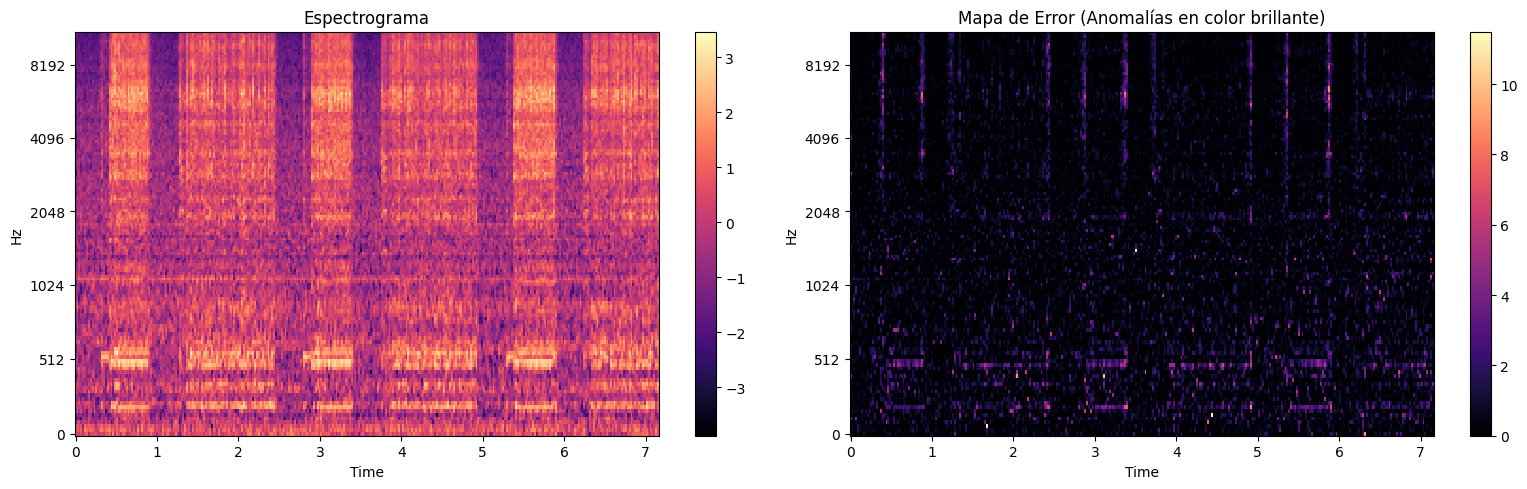

In [4]:
model = tf.keras.models.load_model("../models/baseline/baseline_model_slider_00.keras")

visualize_baseline_error_map(anomaly_file, model, scaler)

In [5]:
def visualize_anomaly_on_waveform(file_path, model, scaler, n_mels=128, frames=5, hop_length=512):
    y, sr = librosa.load(file_path, sr=None)
    time = np.linspace(0, len(y) / sr, num=len(y))

    vectors = file_to_vector_array(file_path, n_mels=n_mels, frames=frames, hop_length=hop_length)
    vectors_scaled = scaler.transform(vectors)
    reconstructed = model.predict(vectors_scaled, verbose=0)
    
    mse_per_frame = np.mean(np.square(vectors_scaled - reconstructed), axis=1)

    # Los frames del espectrograma están centrados en tiempos específicos
    # El primer frame está en t=0 (aprox), el siguiente en hop_length/sr...
    frame_times = librosa.frames_to_time(np.arange(len(mse_per_frame)), sr=sr, hop_length=hop_length)

    threshold = np.percentile(mse_per_frame, 95)
    anomalous_frames = mse_per_frame > threshold

    plt.figure(figsize=(15, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(time, y, color='gray', alpha=0.5, label='Señal Original')
    
    for i, is_anomaly in enumerate(anomalous_frames):
        if is_anomaly:
            t_start = frame_times[i]
            t_end = t_start + (hop_length/sr)
            plt.axvspan(t_start, t_end, color='red', alpha=0.3)
    
    plt.title(f'Detección de Anomalías en el Tiempo: {os.path.basename(file_path)}')
    plt.ylabel('Amplitud')
    plt.legend(['Señal (Zonas Rojas = Error Alto)'])

    plt.subplot(2, 1, 2)
    plt.plot(frame_times, mse_per_frame, color='darkorange', label='MSE de Reconstrucción')
    plt.axhline(y=threshold, color='red', linestyle='--', label='Umbral (P95)')
    plt.fill_between(frame_times, mse_per_frame, threshold, where=(mse_per_frame > threshold), color='red', alpha=0.3)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Error (MSE)')
    plt.legend()

    plt.tight_layout()
    plt.show()

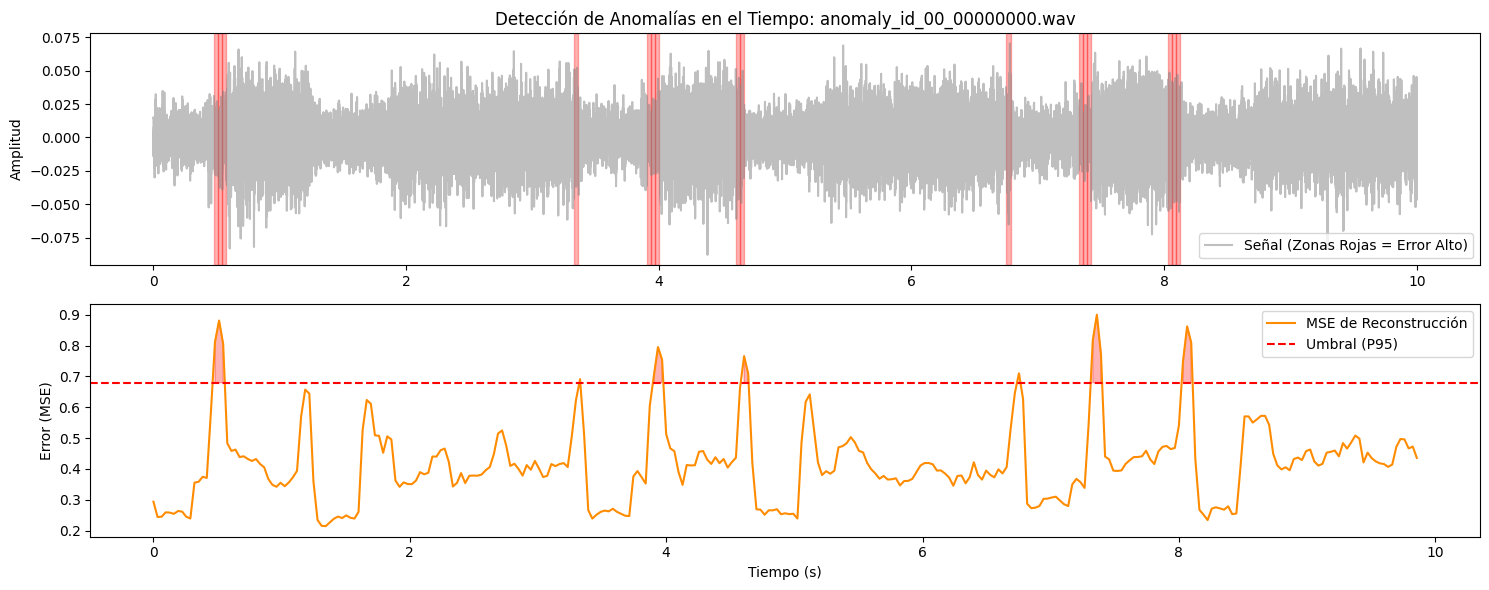

In [6]:
visualize_anomaly_on_waveform(anomaly_file, model, scaler)